# Import the libraries



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Load the dataset


In [2]:
# ============================================================
# Download the Adult dataset automatically in Google Colab
# ============================================================

import pandas as pd
import os

dataset_path = "adult-all.csv"

if not os.path.exists(dataset_path):

    print("Downloading Adult dataset...")

    url = "https://zenodo.org/records/7214275/files/adult.csv"

    dataset = pd.read_csv(url)

    dataset.to_csv(
        dataset_path,
        index=False
    )

    print("Dataset downloaded successfully!")

else:

    print("Dataset already exists.")

    dataset = pd.read_csv(dataset_path)


print("Dataset shape:", dataset.shape)
dataset.head()

Dataset downloaded successfully!
Dataset shape: (32560, 15)


,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [3]:
# Separate the features (x) and target variable (y)
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [4]:
print (x)

[[50 ' Self-emp-not-inc' 83311 ... 0 13 ' United-States']
 [38 ' Private' 215646 ... 0 40 ' United-States']
 [53 ' Private' 234721 ... 0 40 ' United-States']
 ...
 [58 ' Private' 151910 ... 0 40 ' United-States']
 [22 ' Private' 201490 ... 0 20 ' United-States']
 [52 ' Self-emp-inc' 287927 ... 0 40 ' United-States']]


In [5]:
print(y)

[' <=50K' ' <=50K' ' <=50K' ... ' <=50K' ' <=50K' ' >50K']


In [6]:
# Find and handle missing values
x[x == '?'] = np.nan


In [7]:
# Convert column types so missing values can be handled
for i in range(x.shape[1]):
    if np.issubdtype(x[:, i].dtype, np.number):
        mean_value = np.nanmean(x[:, i].astype(float))
        x[:, i] = np.where(np.isnan(x[:, i].astype(float)), mean_value, x[:, i].astype(float))
    else:
        mode_value = pd.Series(x[:, i]).mode()[0]
        x[:, i] = np.where(pd.isnull(x[:, i]), mode_value, x[:, i])

In [8]:
print(x[27])


[39 ' Private' 367260 ' HS-grad' 9 ' Divorced' ' Exec-managerial'
 ' Not-in-family' ' White' ' Male' 0 0 80 ' United-States']


In [9]:
# Encode the feature values
for i in range(x.shape[1]):
    if not np.issubdtype(x[:, i].dtype, np.number):
        unique_values = np.unique(x[:, i])
        encoding = {value: index for index, value in enumerate(unique_values)}
        x[:, i] = np.vectorize(encoding.get)(x[:, i])


In [10]:
# Encode the target labels
unique_values_y = np.unique(y)
encoding_y = {value: index for index, value in enumerate(unique_values_y)}
y = np.vectorize(encoding_y.get)(y)


In [11]:
print("Encoded x:")
print(x)

Encoded x:
[[33 6 2925 ... 0 12 39]
 [21 4 14085 ... 0 39 39]
 [36 4 15335 ... 0 39 39]
 ...
 [41 4 7882 ... 0 39 39]
 [5 4 12880 ... 0 19 39]
 [35 5 17824 ... 0 39 39]]


In [12]:
print("\nEncoded y:")
print(y)


Encoded y:
[0 0 0 ... 0 0 1]


In [13]:
# Shuffle the sample indices
num_samples = len(x)
indices = np.random.permutation(num_samples)


In [14]:
# Split the data into 80% training and 20% testing sets
split_index = int(0.8 * num_samples)

In [15]:
# Split the dataset into training and test sets
x_train, x_test = x[:split_index], x[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


In [16]:
# Show the shapes of the training and test sets
print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (26048, 14)
Shape of x_test: (6512, 14)
Shape of y_train: (26048,)
Shape of y_test: (6512,)


In [17]:
# Apply min-max scaling to the training and test features
def min_max_scaling(data):
    min_vals = np.min(data, axis=0)
    max_vals = np.max(data, axis=0)
    scaled_data = (data - min_vals) / (max_vals - min_vals)
    return scaled_data, min_vals, max_vals

x_train_scaled, min_vals_train, max_vals_train = min_max_scaling(x_train.astype(float))
x_test_scaled = (x_test.astype(float) - min_vals_train) / (max_vals_train - min_vals_train)


In [18]:
# Show the scaled features
print("Scaled x_train:")
print(x_train_scaled)

print("\nScaled x_test:")
print(x_test_scaled)

Scaled x_train:
[[0.45833333 0.75       0.13512889 ... 0.         0.12903226 0.95121951]
 [0.29166667 0.5        0.65069759 ... 0.         0.41935484 0.95121951]
 [0.5        0.5        0.70844498 ... 0.         0.41935484 0.95121951]
 ...
 [0.26388889 0.5        0.15249931 ... 0.         0.41935484 0.95121951]
 [0.33333333 0.875      0.02855031 ... 0.         0.41935484 0.95121951]
 [0.18055556 0.5        0.79127783 ... 0.         0.41935484 0.95121951]]

Scaled x_test:
[[0.05555556 0.5        0.65208353 ... 0.         0.3655914  0.95121951]
 [0.22222222 0.5        0.53423265 ... 0.         0.41935484 0.95121951]
 [0.02777778 0.         0.3274046  ... 0.         0.15053763 0.95121951]
 ...
 [0.56944444 0.5        0.36413194 ... 0.         0.41935484 0.95121951]
 [0.06944444 0.5        0.5950291  ... 0.         0.20430108 0.95121951]
 [0.48611111 0.625      0.82343158 ... 0.         0.41935484 0.95121951]]


In [19]:
import xgboost as xgb


In [20]:
# Convert the data to DMatrix, XGBoost's internal format
dtrain = xgb.DMatrix(x_train_scaled, label=y_train)
dtest = xgb.DMatrix(x_test_scaled)


In [21]:
params = {
    'objective': 'binary:logistic',  # Binary classification objective
    'eval_metric': ['error'],         # Use classification error as the evaluation metric
    'max_depth': 3,                   # Maximum tree depth
    'learning_rate': 0.1,             # Step size used for each boosting update
    'subsample': 0.8,                 # Fraction of training samples used for each tree
    'colsample_bytree': 0.8,          # Fraction of columns used when building each tree
    'seed': 42                        # Use a fixed random seed for reproducibility
}

In [22]:
# Train the XGBoost model with early stopping
num_round = 1000  # Set the maximum number of boosting rounds
watchlist = [(dtrain, 'train')]

evals_result = {}  # Store the evaluation results here

# Use the early_stopping_rounds setting here
bst = xgb.train(
    params,
    dtrain,
    num_round,
    evals=watchlist,
    evals_result=evals_result,
    early_stopping_rounds=10  # Stop if the evaluation score does not improve for 10 rounds
)




[0]	train-error:0.23960
[1]	train-error:0.23960
[2]	train-error:0.23960
[3]	train-error:0.23430
[4]	train-error:0.19925
[5]	train-error:0.19925
[6]	train-error:0.19875
[7]	train-error:0.19003
[8]	train-error:0.18746
[9]	train-error:0.16777
[10]	train-error:0.15652
[11]	train-error:0.15352
[12]	train-error:0.15329
[13]	train-error:0.15276
[14]	train-error:0.15295
[15]	train-error:0.15095
[16]	train-error:0.15061
[17]	train-error:0.15007
[18]	train-error:0.15038
[19]	train-error:0.15038
[20]	train-error:0.15007
[21]	train-error:0.14984
[22]	train-error:0.14696
[23]	train-error:0.14723
[24]	train-error:0.14700
[25]	train-error:0.14688
[26]	train-error:0.14711
[27]	train-error:0.14635
[28]	train-error:0.14600
[29]	train-error:0.14569
[30]	train-error:0.14569
[31]	train-error:0.14562
[32]	train-error:0.14565
[33]	train-error:0.14481
[34]	train-error:0.14477
[35]	train-error:0.14404
[36]	train-error:0.14396
[37]	train-error:0.14393
[38]	train-error:0.14408
[39]	train-error:0.14396
[40]	train

In [23]:
# Generate predictions for the test set
y_pred_prob = bst.predict(dtest)
y_pred = np.round(y_pred_prob)


In [24]:
# Convert the predictions back to the original labels
y_pred_original = np.vectorize({index: value for value, index in encoding_y.items()}.get)(y_pred.astype(int))


In [25]:
# Evaluate the model's predictions
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.870546683046683


In [26]:
# Logistic Regression prediction
def logistic_regression_predict(features, weights):
    logits = np.dot(features, weights)
    probabilities = 1 / (1 + np.exp(-logits))
    return probabilities

In [27]:
# Train the Logistic Regression model
def logistic_regression_train(features, labels, learning_rate=0.01, num_epochs=1000):
    num_samples, num_features = features.shape
    weights = np.zeros(num_features)
    accuracies = []

    for epoch in range(num_epochs):
        predictions = logistic_regression_predict(features, weights)
        errors = labels - predictions
        gradient = np.dot(features.T, errors) / num_samples
        weights += learning_rate * gradient

        # Track accuracy on the training set
        train_predictions = (logistic_regression_predict(features, weights) > 0.5).astype(int)
        train_accuracy = np.mean(train_predictions == labels)
        accuracies.append(train_accuracy)

    return weights, accuracies

In [28]:
# Logistic Regression prediction
def logistic_regression_predict(features, weights):
    logits = np.dot(features, weights)
    probabilities = 1 / (1 + np.exp(-logits))
    return probabilities

In [29]:
# Train the Logistic Regression model
weights, accuracies = logistic_regression_train(x_train_scaled, y_train)

In [30]:
# Generate predictions for the test set
test_predictions = (logistic_regression_predict(x_test_scaled, weights) > 0.5).astype(int)

In [31]:
# Check accuracy on the test set
accuracy = np.mean(test_predictions == y_test)
print(f"Logistic Regression Test Accuracy: {accuracy}")

Logistic Regression Test Accuracy: 0.7542997542997543


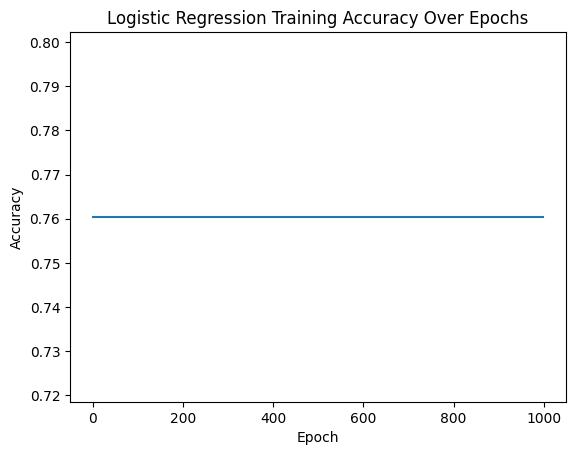

In [32]:
# Plot the training accuracy
plt.plot(accuracies)
plt.title('Logistic Regression Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [33]:
# Train the Linear Regression model
def linear_regression_train(features, labels, learning_rate=0.01, num_epochs=10):
    num_samples, num_features = features.shape
    weights = np.zeros(num_features)
    biases = 0
    losses = []

    for epoch in range(num_epochs):
        predictions = linear_regression_predict(features, weights, biases)
        errors = labels - predictions
        gradient_weights = -2 * np.dot(errors, features) / num_samples
        gradient_biases = -2 * np.sum(errors) / num_samples
        weights -= learning_rate * gradient_weights
        biases -= learning_rate * gradient_biases

        # Calculate the mean squared loss
        mean_squared_loss = np.mean(errors ** 2)
        losses.append(mean_squared_loss)

    return weights, biases, losses

In [34]:
# Linear Regression prediction
def linear_regression_predict(features, weights, biases):
    return np.dot(features, weights) + biases

In [35]:
# Train the Linear Regression model
weights, biases, losses = linear_regression_train(x_train_scaled, y_train)

In [36]:
# Generate predictions for the test set
test_predictions = linear_regression_predict(x_test_scaled, weights, biases)


In [37]:
# Calculate the test mean squared loss
test_errors = y_test - test_predictions
test_mean_squared_loss = np.mean(test_errors ** 2)
print(f"Linear Regression Test Mean Squared Loss: {test_mean_squared_loss}")


Linear Regression Test Mean Squared Loss: 0.18653145536388788


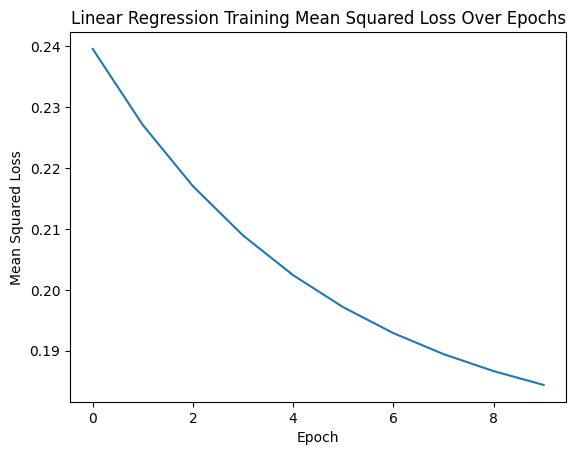

In [38]:
# Plot the training loss
plt.plot(losses)
plt.title('Linear Regression Training Mean Squared Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Loss')
plt.show()

In [39]:
# Node used by the Decision Tree
class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index  # Feature index used for the split
        self.threshold = threshold  # Threshold used for the split
        self.left = left  # Left subtree
        self.right = right  # Right subtree
        self.value = value  # Class label stored in a leaf node

In [41]:
import numpy as np

class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, features, labels):
        self.tree = self._build_tree(features, labels, depth=0)

    def _build_tree(self, features, labels, depth):
        unique_labels, counts = np.unique(labels, return_counts=True)

        # Create a leaf if all labels match or max depth is reached
        if len(unique_labels) == 1 or (self.max_depth is not None and depth == self.max_depth):
            return {'label': unique_labels[0], 'count': counts[0]}

        # Find the split with the lowest Gini impurity
        split_column, split_value = self._find_best_split(features, labels)

        if split_column is None:
            # No valid split was found, so create a leaf
            return {'label': unique_labels[np.argmax(counts)], 'count': np.sum(counts)}

        # Split the data at the chosen value
        left_mask = features[:, split_column] <= split_value
        right_mask = ~left_mask

        # Build both subtrees recursively
        left_subtree = self._build_tree(features[left_mask], labels[left_mask], depth + 1)
        right_subtree = self._build_tree(features[right_mask], labels[right_mask], depth + 1)

        return {
            'column': split_column,
            'value': split_value,
            'left': left_subtree,
            'right': right_subtree
        }

    def _find_best_split(self, features, labels):

        best_gini = float("inf")
        best_column = None
        best_value = None

        n_samples, n_features = features.shape

        # Try each feature and each possible split value
        for column in range(n_features):

            values = np.unique(features[:, column])

            for value in values:

                left_mask = features[:, column] <= value
                right_mask = ~left_mask

                # Skip splits that leave one side empty
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                left_labels = labels[left_mask]
                right_labels = labels[right_mask]

                # Calculate the Gini impurity
                def gini(y):
                    _, counts = np.unique(y, return_counts=True)
                    probabilities = counts / len(y)
                    return 1 - np.sum(probabilities ** 2)

                weighted_gini = (
                    (len(left_labels) / n_samples) * gini(left_labels)
                    +
                    (len(right_labels) / n_samples) * gini(right_labels)
                )

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_column = column
                    best_value = value

        return best_column, best_value

    def _predict_tree(self, node, feature):

        if 'label' in node:
            # Leaf node
            return node['label']

        # Internal node: choose the left or right subtree
        if feature[node['column']] <= node['value']:
            return self._predict_tree(node['left'], feature)
        else:
            return self._predict_tree(node['right'], feature)

    def predict(self, features):
        return np.array([
            self._predict_tree(self.tree, feature)
            for feature in features
        ])


# Use the preprocessed training and test data
# x_train_scaled, x_test_scaled, y_train, and y_test


# Create a Decision Tree instance
tree = DecisionTree(max_depth=3)


# Train the Decision Tree
tree.fit(x_train_scaled, y_train)


# Generate predictions for the test set
test_predictions = tree.predict(x_test_scaled)


# Check accuracy on the test set
accuracy = np.mean(test_predictions == y_test)

print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.7542997542997543


In [43]:
import numpy as np


class DecisionTree:

    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None


    def fit(self, features, labels):
        self.tree = self._build_tree(features, labels, depth=0)


    def _build_tree(self, features, labels, depth):

        # Handle empty nodes
        if len(labels) == 0:
            return None


        unique_labels, counts = np.unique(
            labels,
            return_counts=True
        )


        # Create a leaf if all labels match or max depth is reached
        if (
            len(unique_labels) == 1
            or
            (
                self.max_depth is not None
                and depth >= self.max_depth
            )
        ):
            return {
                'label': unique_labels[np.argmax(counts)],
                'count': np.sum(counts)
            }


        # Find the best split
        split_column, split_value = self._find_best_split(
            features,
            labels
        )


        if split_column is None:
            return {
                'label': unique_labels[np.argmax(counts)],
                'count': np.sum(counts)
            }


        # Split the data
        left_mask = features[:, split_column] <= split_value
        right_mask = ~left_mask


        # Avoid splits that create an empty side
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return {
                'label': unique_labels[np.argmax(counts)],
                'count': np.sum(counts)
            }


        # Build the tree recursively
        left_subtree = self._build_tree(
            features[left_mask],
            labels[left_mask],
            depth + 1
        )


        right_subtree = self._build_tree(
            features[right_mask],
            labels[right_mask],
            depth + 1
        )


        return {
            'column': split_column,
            'value': split_value,
            'left': left_subtree,
            'right': right_subtree
        }



    def _find_best_split(self, features, labels):

        # Use a random split for this example
        num_features = features.shape[1]

        split_column = np.random.randint(
            0,
            num_features
        )

        split_value = np.median(
            features[:, split_column]
        )

        return split_column, split_value



    def _predict_tree(self, node, feature):

        # Check that the node exists
        if node is None:
            return None


        if 'label' in node:
            return node['label']


        if feature[node['column']] <= node['value']:

            return self._predict_tree(
                node['left'],
                feature
            )

        else:

            return self._predict_tree(
                node['right'],
                feature
            )



    def predict(self, features):

        return np.array(
            [
                self._predict_tree(self.tree, feature)
                for feature in features
            ]
        )



# Use the preprocessed training and test data
# x_train_scaled, x_test_scaled, y_train, and y_test


# Create a Decision Tree instance
tree = DecisionTree(max_depth=3)


# Train the tree
tree.fit(
    x_train_scaled,
    y_train
)


# Make predictions
test_predictions = tree.predict(
    x_test_scaled
)


# Calculate accuracy
accuracy = np.mean(
    test_predictions == y_test
)


print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.7982186732186732


In [44]:
class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, features, labels):
        self.tree = self._build_tree(features, labels, depth=0)

    def _build_tree(self, features, labels, depth):
        if len(labels) == 0:
            # If this subset is empty, create a leaf node
            return {'label': None, 'count': 0}

        unique_labels, counts = np.unique(labels, return_counts=True)

        # Create a leaf if all labels match or max depth is reached
        if len(unique_labels) == 1 or (self.max_depth is not None and depth == self.max_depth):
            return {'label': unique_labels[0], 'count': counts[0]}

        # Find the split with the lowest Gini impurity
        split_column, split_value = self._find_best_split(features, labels)

        if split_column is None:
            # No valid split was found, so create a leaf
            return {'label': unique_labels[np.argmax(counts)], 'count': np.sum(counts)}

        # Split the data at the chosen value
        left_mask = features[:, split_column] <= split_value
        right_mask = ~left_mask

        # Build both subtrees recursively
        left_subtree = self._build_tree(features[left_mask], labels[left_mask], depth + 1)
        right_subtree = self._build_tree(features[right_mask], labels[right_mask], depth + 1)

        return {'column': split_column, 'value': split_value,
                'left': left_subtree, 'right': right_subtree}

    def _find_best_split(self, features, labels):
        num_samples, num_features = features.shape
        gini_parent = self._calculate_gini(labels)

        best_gini_reduction = 0
        best_split_column = None
        best_split_value = None

        for col in range(num_features):
            unique_values = np.unique(features[:, col])

            for value in unique_values:
                left_mask = features[:, col] <= value
                right_mask = ~left_mask

                gini_left = self._calculate_gini(labels[left_mask])
                gini_right = self._calculate_gini(labels[right_mask])

                weight_left = len(labels[left_mask]) / num_samples
                weight_right = len(labels[right_mask]) / num_samples

                weighted_avg_gini = weight_left * gini_left + weight_right * gini_right
                gini_reduction = gini_parent - weighted_avg_gini

                if gini_reduction > best_gini_reduction:
                    best_gini_reduction = gini_reduction
                    best_split_column = col
                    best_split_value = value

        return best_split_column, best_split_value

    def _calculate_gini(self, labels):
        if len(labels) == 0:
            return 0

        unique_labels, counts = np.unique(labels, return_counts=True)
        probabilities = counts / len(labels)
        gini = 1 - np.sum(probabilities ** 2)

        return gini

    def predict(self, features):
        return np.array([self._predict_tree(self.tree, feature) for feature in features])

    def _predict_tree(self, node, feature):
        if 'label' in node:
            # At a leaf, return its label
            return node['label']
        else:
            # At an internal node, follow the split condition to the left or right
            split_column = node['column']
            split_value = node['value']

            if feature[split_column] <= split_value:
                return self._predict_tree(node['left'], feature)
            else:
                return self._predict_tree(node['right'], feature)

In [45]:
# Train the Decision Tree
tree = DecisionTree(max_depth=3)
tree.fit(x_train_scaled, y_train)

In [46]:
# Generate predictions for the test set
test_predictions = tree.predict(x_test_scaled)

In [47]:
# Check accuracy on the test set
accuracy = np.mean(test_predictions == y_test)
print(f"Decision Tree Test Accuracy: {accuracy}")

Decision Tree Test Accuracy: 0.7542997542997543


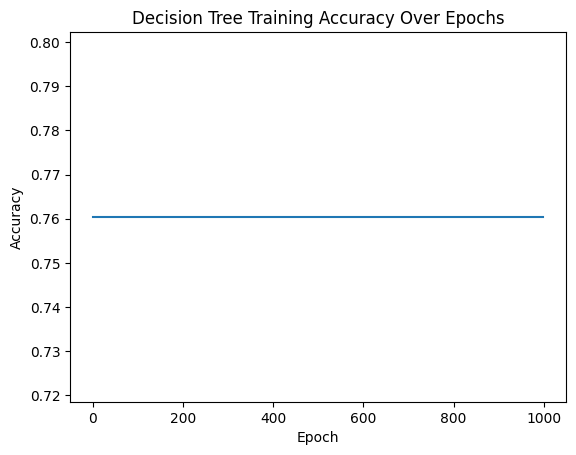

In [48]:
# Plot the training accuracy
plt.plot(accuracies)
plt.title('Decision Tree Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [49]:
class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, features, labels):
        self.tree = self._build_tree(features, labels, depth=0)

    def _build_tree(self, features, labels, depth):
        unique_labels, counts = np.unique(labels, return_counts=True)

        # Create a leaf if all labels match or max depth is reached
        if len(unique_labels) == 1 or (self.max_depth is not None and depth == self.max_depth):
            return {'label': unique_labels[0], 'count': counts[0]}

        # Find the best split using information gain
        split_column, split_value = self._find_best_split(features, labels)

        if split_column is None:
            return {'label': unique_labels[np.argmax(counts)], 'count': np.sum(counts)}

        left_mask = features[:, split_column] <= split_value
        right_mask = ~left_mask

        # Build both subtrees recursively
        left_subtree = self._build_tree(features[left_mask], labels[left_mask], depth + 1)
        right_subtree = self._build_tree(features[right_mask], labels[right_mask], depth + 1)

        return {'column': split_column, 'value': split_value,
                'left': left_subtree, 'right': right_subtree}

    def _find_best_split(self, features, labels):
        num_samples, num_features = features.shape
        best_split_column, best_split_value, best_info_gain = None, None, -1

        for column in range(num_features):
            feature_values = features[:, column]
            unique_values = np.unique(feature_values)

            for value in unique_values:
                left_mask = feature_values <= value
                right_mask = ~left_mask

                left_labels, right_labels = labels[left_mask], labels[right_mask]
                info_gain = self._information_gain(labels, left_labels, right_labels)

                if info_gain > best_info_gain:
                    best_split_column, best_split_value, best_info_gain = column, value, info_gain

        return best_split_column, best_split_value

    def _information_gain(self, parent_labels, left_labels, right_labels):
        parent_entropy = self._entropy(parent_labels)
        left_weight = len(left_labels) / len(parent_labels)
        right_weight = len(right_labels) / len(parent_labels)

        left_entropy = self._entropy(left_labels)
        right_entropy = self._entropy(right_labels)

        return parent_entropy - (left_weight * left_entropy + right_weight * right_entropy)

    def _entropy(self, labels):
        _, counts = np.unique(labels, return_counts=True)
        probabilities = counts / len(labels)
        return -np.sum(probabilities * np.log2(probabilities + 1e-10))

    def predict(self, features):
        return np.array([self._predict_tree(self.tree, feature) for feature in features])

    def _predict_tree(self, node, feature):
        if 'label' in node:
            return node['label']
        else:
            if feature[node['column']] <= node['value']:
                return self._predict_tree(node['left'], feature)
            else:
                return self._predict_tree(node['right'], feature)

In [50]:
# Train the Decision Tree using information gain
tree = DecisionTree(max_depth=3)
tree.fit(x_train_scaled, y_train)

In [51]:
# Generate predictions for the test set
test_predictions = tree.predict(x_test_scaled)

In [52]:
# Check accuracy on the test set
accuracy = np.mean(test_predictions == y_test)
print(f"Decision Tree Test Accuracy: {accuracy}")


Decision Tree Test Accuracy: 0.7628992628992629


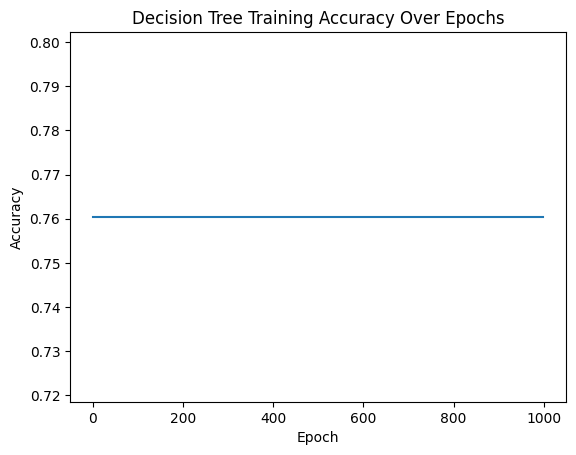

In [53]:
# Plot the training accuracy
plt.plot(accuracies)
plt.title('Decision Tree Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [54]:
class NaiveBayesClassifier:
    def __init__(self):
        self.class_probs = None
        self.feature_probs = None

    def fit(self, X_train, y_train):
        num_samples, num_features = X_train.shape
        unique_classes = np.unique(y_train)
        num_classes = len(unique_classes)

        # Calculate the class probabilities
        class_probs = {c: np.sum(y_train == c) / num_samples for c in unique_classes}

        # Calculate the feature probabilities
        feature_probs = {}
        for c in unique_classes:
            class_mask = (y_train == c)
            feature_probs[c] = [
                (np.sum(X_train[class_mask, i] == val) + 1) / (np.sum(class_mask) + len(np.unique(X_train[:, i])))
                for i in range(num_features)
                for val in np.unique(X_train[:, i])
            ]

        self.class_probs = class_probs
        self.feature_probs = feature_probs

    def predict(self, X_test):
        num_samples, num_features = X_test.shape
        predictions = []

        for i in range(num_samples):
            posteriors = {}
            for c, class_prob in self.class_probs.items():
                feature_probs = self.feature_probs[c]
                likelihood = np.prod([
                    feature_probs[j * len(np.unique(X_test[:, j])) + np.where(np.unique(X_test[:, j]) == X_test[i, j])[0][0]]
                    for j in range(num_features)
                ])
                posteriors[c] = class_prob * likelihood

            prediction = max(posteriors, key=posteriors.get)
            predictions.append(prediction)

        return np.array(predictions)

In [55]:
# Example usage:
# Use x_train and y_train for training, and x_test for testing
# Create a Naive Bayes classifier
nb_classifier = NaiveBayesClassifier()

In [56]:
# Train the model
nb_classifier.fit(x_train, y_train)

In [57]:
# Generate predictions for the test set
nb_predictions = nb_classifier.predict(x_test)

In [58]:
# Check the accuracy
nb_accuracy = np.mean(nb_predictions == y_test)
print(f"Naive Bayes Test Accuracy: {nb_accuracy}")

Naive Bayes Test Accuracy: 0.7231265356265356


In [59]:
# Compute PCA manually
cov_matrix = np.cov(x_train_scaled, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

In [60]:
# Sort the eigenvalues and eigenvectors from largest to smallest
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]


In [61]:
# Keep enough components to retain 95% of the variance
total_variance = np.sum(eigenvalues)
cumulative_variance = np.cumsum(eigenvalues) / total_variance
num_components = np.argmax(cumulative_variance >= 0.95) + 1

In [62]:
# Project the data onto the selected principal components
projection_matrix = eigenvectors[:, :num_components]
x_train_pca = x_train_scaled.dot(projection_matrix)
x_test_pca = x_test_scaled.dot(projection_matrix)

In [63]:
# Convert the data to DMatrix, XGBoost's internal format
dtrain = xgb.DMatrix(x_train_pca, label=y_train)
dtest = xgb.DMatrix(x_test_pca, label=y_test)


In [64]:
# Set the XGBoost hyperparameters
params = {
    'objective': 'binary:logistic',  # Binary classification objective
    'eval_metric': ['error'],         # Use classification error as the evaluation metric
    'max_depth': 3,                   # Maximum tree depth
    'learning_rate': 0.1,             # Step size used for each boosting update
    'subsample': 0.8,                 # Fraction of training samples used for each tree
    'colsample_bytree': 0.8,          # Fraction of columns used when building each tree
    'seed': 42                        # Use a fixed random seed for reproducibility
}


In [65]:
# Train the XGBoost model with early stopping
num_round = 1000  # Set the maximum number of boosting rounds
watchlist = [(dtrain, 'train')]

evals_result = {}  # Store the evaluation results here

In [66]:
# Use the early_stopping_rounds setting here
bst = xgb.train(
    params,
    dtrain,
    num_round,
    evals=watchlist,
    evals_result=evals_result,
    early_stopping_rounds=10  # Stop if the evaluation score does not improve for 10 rounds
)


[0]	train-error:0.23960
[1]	train-error:0.23960
[2]	train-error:0.23960
[3]	train-error:0.23960
[4]	train-error:0.20854
[5]	train-error:0.20766
[6]	train-error:0.20762
[7]	train-error:0.20574
[8]	train-error:0.19426
[9]	train-error:0.17644
[10]	train-error:0.17786
[11]	train-error:0.16746
[12]	train-error:0.16404
[13]	train-error:0.16389
[14]	train-error:0.16216
[15]	train-error:0.16036
[16]	train-error:0.16055
[17]	train-error:0.15994
[18]	train-error:0.15997
[19]	train-error:0.15986
[20]	train-error:0.15871
[21]	train-error:0.15852
[22]	train-error:0.15821
[23]	train-error:0.15825
[24]	train-error:0.15640
[25]	train-error:0.15652
[26]	train-error:0.15579
[27]	train-error:0.15575
[28]	train-error:0.15533
[29]	train-error:0.15502
[30]	train-error:0.15518
[31]	train-error:0.15475
[32]	train-error:0.15429
[33]	train-error:0.15441
[34]	train-error:0.15418
[35]	train-error:0.15429
[36]	train-error:0.15418
[37]	train-error:0.15422
[38]	train-error:0.15410
[39]	train-error:0.15425
[40]	train

In [67]:
# Check accuracy on the test set
test_predictions = (bst.predict(dtest) > 0.5).astype(int)
accuracy = np.mean(test_predictions == y_test)
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.8525798525798526


In [68]:
# Logistic Regression prediction
def logistic_regression_predict(features, weights):
    logits = np.dot(features, weights)
    probabilities = 1 / (1 + np.exp(-logits))
    return probabilities

In [69]:
# Train the Logistic Regression model
def logistic_regression_train(features, labels, learning_rate=0.01, num_epochs=1000):
    num_samples, num_features = features.shape
    weights = np.zeros(num_features)
    accuracies = []

    for epoch in range(num_epochs):
        predictions = logistic_regression_predict(features, weights)
        errors = labels - predictions
        gradient = np.dot(features.T, errors) / num_samples
        weights += learning_rate * gradient

        # Track accuracy on the training set
        train_predictions = (logistic_regression_predict(features, weights) > 0.5).astype(int)
        train_accuracy = np.mean(train_predictions == labels)
        accuracies.append(train_accuracy)

    return weights, accuracies

In [70]:
# Logistic Regression prediction
def logistic_regression_predict(features, weights):
    logits = np.dot(features, weights)
    probabilities = 1 / (1 + np.exp(-logits))
    return probabilities

In [71]:
# Train the Logistic Regression model
weights, accuracies = logistic_regression_train(x_train_pca, y_train)

In [72]:
# Generate predictions for the test set
test_predictions = (logistic_regression_predict(x_test_pca, weights) > 0.5).astype(int)

In [73]:
# Check accuracy on the test set
accuracy = np.mean(test_predictions == y_test)
print(f"Logistic Regression Test Accuracy: {accuracy}")

Logistic Regression Test Accuracy: 0.7542997542997543


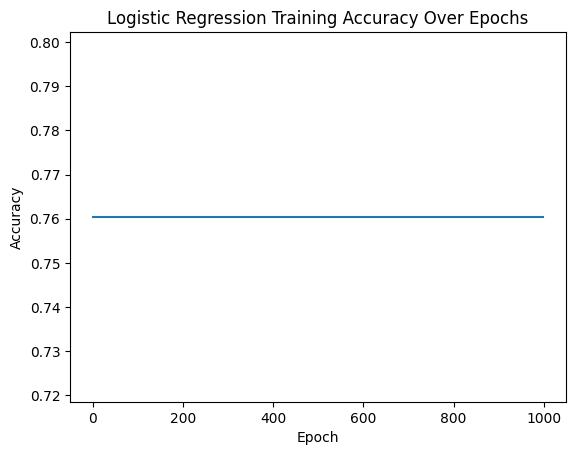

In [74]:
# Plot the training accuracy
plt.plot(accuracies)
plt.title('Logistic Regression Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [75]:
# Train the Linear Regression model
def linear_regression_train(features, labels, learning_rate=0.01, num_epochs=10):
    num_samples, num_features = features.shape
    weights = np.zeros(num_features)
    biases = 0
    losses = []

    for epoch in range(num_epochs):
        predictions = linear_regression_predict(features, weights, biases)
        errors = labels - predictions
        gradient_weights = -2 * np.dot(errors, features) / num_samples
        gradient_biases = -2 * np.sum(errors) / num_samples
        weights -= learning_rate * gradient_weights
        biases -= learning_rate * gradient_biases

        # Calculate the mean squared loss
        mean_squared_loss = np.mean(errors ** 2)
        losses.append(mean_squared_loss)

    return weights, biases, losses

In [76]:
# Linear Regression prediction
def linear_regression_predict(features, weights, biases):
    return np.dot(features, weights) + biases

In [77]:
# Train the Linear Regression model
weights, biases, losses = linear_regression_train(x_train_pca, y_train)

In [78]:
# Generate predictions for the test set
test_predictions = linear_regression_predict(x_test_pca, weights, biases)


In [79]:
# Calculate the test mean squared loss
test_errors = y_test - test_predictions
test_mean_squared_loss = np.mean(test_errors ** 2)
print(f"Linear Regression Test Mean Squared Loss: {test_mean_squared_loss}")


Linear Regression Test Mean Squared Loss: 0.18689690185139576


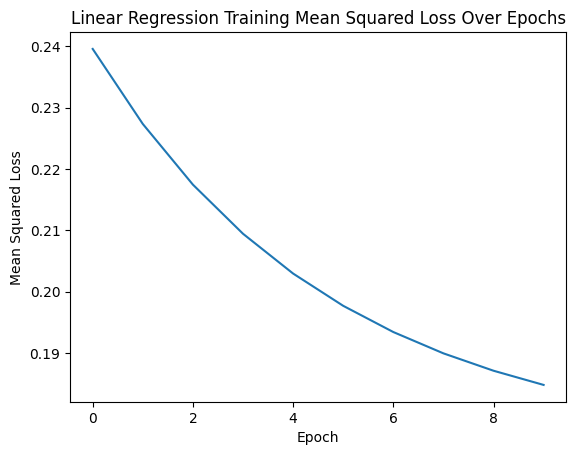

In [80]:
# Plot the training loss
plt.plot(losses)
plt.title('Linear Regression Training Mean Squared Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Loss')
plt.show()

In [81]:
# Train the Decision Tree
tree = DecisionTree(max_depth=3)
tree.fit(x_train_pca, y_train)

In [82]:
# Generate predictions for the test set
test_predictions = tree.predict(x_test_pca)

In [83]:
# Check accuracy on the test set
accuracy = np.mean(test_predictions == y_test)
print(f"Decision Tree Test Accuracy: {accuracy}")

Decision Tree Test Accuracy: 0.7542997542997543


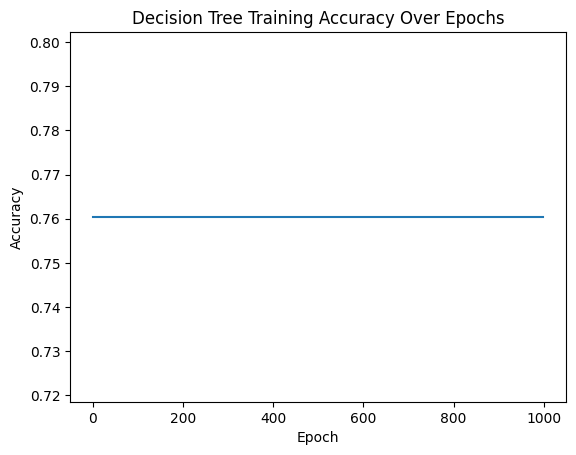

In [84]:
# Plot the training accuracy
plt.plot(accuracies)
plt.title('Decision Tree Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [85]:
# Train the model
nb_classifier.fit(x_train_pca, y_train)

In [ ]:
# Generate predictions for the test set
nb_predictions = nb_classifier.predict(x_test_pca)

In [ ]:
# Check the accuracy
nb_accuracy = np.mean(nb_predictions == y_test)
print(f"Naive Bayes Test Accuracy: {nb_accuracy}")

In [ ]:
def forward_selection(features, labels, max_features=None):
    num_samples, num_features = features.shape
    selected_features = []
    all_features = list(range(num_features))
    remaining_features = set(all_features)

    for _ in range(min(max_features, num_features)):
        best_accuracy = 0
        best_feature = None

        for feature in remaining_features:
            current_features = selected_features + [feature]
            current_data = features[:, current_features]

            _, accuracies = logistic_regression_train(current_data, labels)

            current_accuracy = accuracies[-1]

            if current_accuracy > best_accuracy:
                best_accuracy = current_accuracy
                best_feature = feature

        selected_features.append(best_feature)
        remaining_features.remove(best_feature)

    return selected_features


In [ ]:
# Backward elimination
def backward_elimination(features, labels):
    num_samples, num_features = features.shape
    selected_features = list(range(num_features))

    for _ in range(num_features):
        best_accuracy = 0
        worst_feature = None

        for feature in selected_features:
            current_features = list(set(selected_features) - {feature})
            current_data = features[:, current_features]

            _, accuracies = logistic_regression_train(current_data, labels)

            current_accuracy = accuracies[-1]

            if current_accuracy > best_accuracy:
                best_accuracy = current_accuracy
                worst_feature = feature

        selected_features.remove(worst_feature)

    return selected_features

In [90]:
# Example usage
selected_features_forward = forward_selection(x_train_scaled, y_train, max_features=5)
print("Selected Features (Forward Selection):", selected_features_forward)

selected_features_backward = backward_elimination(x_train_scaled, y_train)
print("Selected Features (Backward Elimination):", selected_features_backward)

Selected Features (Forward Selection): [10, 7, 11, 0, 2]
Selected Features (Backward Elimination): []


In [ ]:

# Use the original scaled data and the selected features below
# selected_features_forward contains the features chosen by forward selection

# Keep only the selected features
x_train_selected = x_train_scaled[:, selected_features_forward]
x_test_selected = x_test_scaled[:, selected_features_forward]

# Convert the data to DMatrix, XGBoost's internal format
dtrain = xgb.DMatrix(x_train_selected, label=y_train)
dtest = xgb.DMatrix(x_test_selected, label=y_test)

# Set the XGBoost hyperparameters
params = {
    'objective': 'binary:logistic',  # Binary classification objective
    'eval_metric': ['error'],         # Use classification error as the evaluation metric
    'max_depth': 3,                   # Maximum tree depth
    'learning_rate': 0.1,             # Step size used for each boosting update
    'subsample': 0.8,                 # Fraction of training samples used for each tree
    'colsample_bytree': 0.8,          # Fraction of columns used when building each tree
    'seed': 42                        # Use a fixed random seed for reproducibility
}

# Train the XGBoost model
num_round = 1000  # Set the maximum number of boosting rounds
watchlist = [(dtrain, 'train')]

evals_result = {}  # Store the evaluation results here

bst = xgb.train(
    params,
    dtrain,
    num_round,
    evals=watchlist,
    evals_result=evals_result,
    early_stopping_rounds=10  # Stop if the evaluation score does not improve for 10 rounds
)

# Check accuracy on the test set
x_test_selected_for_prediction = x_test_scaled[:, selected_features_forward]
dtest_selected = xgb.DMatrix(x_test_selected_for_prediction, label=y_test)
test_predictions = (bst.predict(dtest_selected) > 0.5).astype(int)
accuracy = np.mean(test_predictions == y_test)
print(f"Test Accuracy: {accuracy}")


In [ ]:
# Train the Logistic Regression model
weights, accuracies = logistic_regression_train(x_train_selected, y_train)

In [ ]:
# Generate predictions for the test set
test_predictions = (logistic_regression_predict(x_test_selected, weights) > 0.5).astype(int)

In [ ]:
# Check accuracy on the test set
accuracy = np.mean(test_predictions == y_test)
print(f"Logistic Regression Test Accuracy: {accuracy}")

In [ ]:
# Plot the training accuracy
plt.plot(accuracies)
plt.title('Logistic Regression Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [96]:
# Train the Linear Regression model
weights, biases, losses = linear_regression_train(x_train_selected, y_train)

In [97]:
# Generate predictions for the test set
test_predictions = linear_regression_predict(x_test_selected, weights, biases)

In [98]:
# Calculate the test mean squared loss
test_errors = y_test - test_predictions
test_mean_squared_loss = np.mean(test_errors ** 2)
print(f"Linear Regression Test Mean Squared Loss: {test_mean_squared_loss}")


Linear Regression Test Mean Squared Loss: 0.2195546923866838


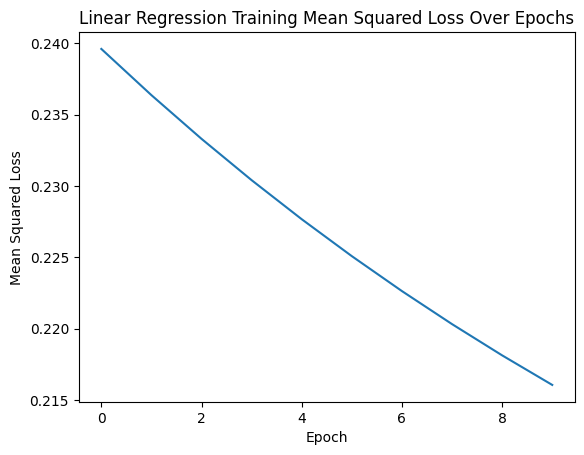

In [99]:
# Plot the training loss
plt.plot(losses)
plt.title('Linear Regression Training Mean Squared Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Loss')
plt.show()

In [100]:
# Train the Decision Tree
tree = DecisionTree(max_depth=3)
tree.fit(x_train_selected, y_train)

In [ ]:
# Generate predictions for the test set
test_predictions = tree.predict(x_test_selected)


In [ ]:
# Check accuracy on the test set
accuracy = np.mean(test_predictions == y_test)
print(f"Decision Tree Test Accuracy: {accuracy}")


In [ ]:
# Plot the training accuracy
plt.plot(accuracies)
plt.title('Decision Tree Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
class NaiveBayesClassifier:
    def predict(self, X_test):
        num_samples, num_features = X_test.shape
        unique_classes = np.unique(self.labels)
        posteriors = np.zeros((num_samples, len(unique_classes)))

        for i in range(num_samples):
            for c, class_prob in self.class_probs.items():
                feature_probs = self.feature_probs[c]
                likelihood = 1.0
                for j in range(num_features):
                    unique_vals = np.unique(X_test[:, j])
                    if X_test[i, j] in unique_vals:
                        index = np.where(unique_vals == X_test[i, j])[0][0]
                        likelihood *= feature_probs[j][index]
                posteriors[i, c] = class_prob * likelihood

        predictions = np.argmax(posteriors, axis=1)
        return predictions


In [105]:
# Train the model
nb_classifier.fit(x_train_selected, y_train)

In [ ]:
# Check the accuracy
nb_accuracy = np.mean(nb_predictions == y_test)
print(f"Naive Bayes Test Accuracy: {nb_accuracy}")

In [110]:
# ============================================================
# Final export cell
# Export all tables and available images from Colab
# ============================================================

import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Create the export folders
# ------------------------------------------------------------

EXPORT_DIR = Path("ML_Project_All_Results_Export")

CSV_DIR = EXPORT_DIR / "CSV_Files"

PNG_DIR = EXPORT_DIR / "PNG_Figures"

FOUND_IMAGES_DIR = EXPORT_DIR / "Found_Images"


CSV_DIR.mkdir(parents=True, exist_ok=True)

PNG_DIR.mkdir(parents=True, exist_ok=True)

FOUND_IMAGES_DIR.mkdir(parents=True, exist_ok=True)



# ------------------------------------------------------------
# 1) Export all pandas DataFrames
# ------------------------------------------------------------

saved_csv = []


for name, obj in list(globals().items()):

    try:

        if isinstance(obj, pd.DataFrame):

            filename = f"{name}.csv"

            obj.to_csv(
                CSV_DIR / filename,
                index=False
            )

            saved_csv.append(filename)

    except:
        pass



# ------------------------------------------------------------
# 2) Save all currently open matplotlib figures
# ------------------------------------------------------------

saved_png = []


figure_ids = plt.get_fignums()


for i, fig_id in enumerate(figure_ids):

    try:

        fig = plt.figure(fig_id)

        filename = f"active_matplotlib_{i+1}.png"

        fig.savefig(
            PNG_DIR / filename,
            dpi=300,
            bbox_inches="tight"
        )

        saved_png.append(filename)

    except:
        pass




# ------------------------------------------------------------
# 3) Search Colab for existing image files
# ------------------------------------------------------------

image_extensions = {

    ".png",
    ".jpg",
    ".jpeg",
    ".svg",
    ".webp",
    ".bmp"

}


found_existing = []


for root, dirs, files in os.walk("/content"):

    for file in files:

        path = Path(root) / file


        if path.suffix.lower() in image_extensions:


            # Skip the export folder itself

            if EXPORT_DIR.name not in str(path):

                destination = (
                    FOUND_IMAGES_DIR /
                    path.name
                )


                try:

                    shutil.copy2(
                        path,
                        destination
                    )

                    found_existing.append(
                        file
                    )

                except:
                    pass




# ------------------------------------------------------------
# 4) Create plots from numeric variables
# ------------------------------------------------------------

generated_from_variables = []


for name, obj in list(globals().items()):

    try:

        data = None


        if isinstance(obj, (list, tuple)):

            if len(obj) > 2 and all(
                isinstance(x, (int,float,np.number))
                for x in obj
            ):
                data = obj



        elif isinstance(obj, np.ndarray):

            if obj.ndim == 1 and len(obj) > 2:

                data = obj



        elif isinstance(obj, pd.Series):

            data = obj.values



        if data is not None:


            plt.figure(figsize=(8,5))


            plt.plot(data)


            plt.title(
                f"{name} plot"
            )


            plt.xlabel(
                "Index"
            )


            plt.ylabel(
                name
            )


            filename = (
                f"auto_generated_{name}.png"
            )


            plt.savefig(
                PNG_DIR / filename,
                dpi=300,
                bbox_inches="tight"
            )


            plt.close()


            generated_from_variables.append(
                filename
            )


    except:
        pass





# ------------------------------------------------------------
# 5) Create the ZIP archive
# ------------------------------------------------------------

zip_file = shutil.make_archive(

    "ML_Project_All_Results_Export",

    "zip",

    EXPORT_DIR

)



# ------------------------------------------------------------
# Report the export results
# ------------------------------------------------------------

print("="*70)

print("FINAL EXPORT FINISHED")

print("="*70)


print(
    "CSV files:",
    len(saved_csv)
)


print(
    "Active matplotlib PNG:",
    len(saved_png)
)


print(
    "Images found in Colab:",
    len(found_existing)
)


print(
    "Auto generated plots:",
    len(generated_from_variables)
)


print()

print(
    "Folder:"
)

print(
    EXPORT_DIR.resolve()
)


print()

print(
    "ZIP:"
)

print(
    zip_file
)


print("="*70)

FINAL EXPORT FINISHED
CSV files: 3
Active matplotlib PNG: 0
Images found in Colab: 2
Auto generated plots: 20

Folder:
/content/ML_Project_All_Results_Export

ZIP:
/content/ML_Project_All_Results_Export.zip
